### IMS bearings — EDA

Failures: `t1b3` inner race, `t1b4` roller element, `t2b1` outer race, `t3b3` outer
race. The other eight bearings finished healthy.

In [1]:
import os

os.chdir('..')
os.getcwd()

'c:\\Users\\chouybat\\repositories\\phm-101'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from phm_101.data_pipeline.data_loader import DataLoader
from phm_101.utils.ims import CHANNELS

loader = DataLoader()

data = loader.load('t2b1')
data.signals.shape, data.signals.dtype, len(data)

2026-08-25 16:20:16.113 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t2b1
2026-08-25 16:20:16.215 | INFO     | phm_101.data_loader:load:84 - Terminated loading IMS raw signals from parquet file for channel t2b1


((982, 20480), dtype('float32'), 982)

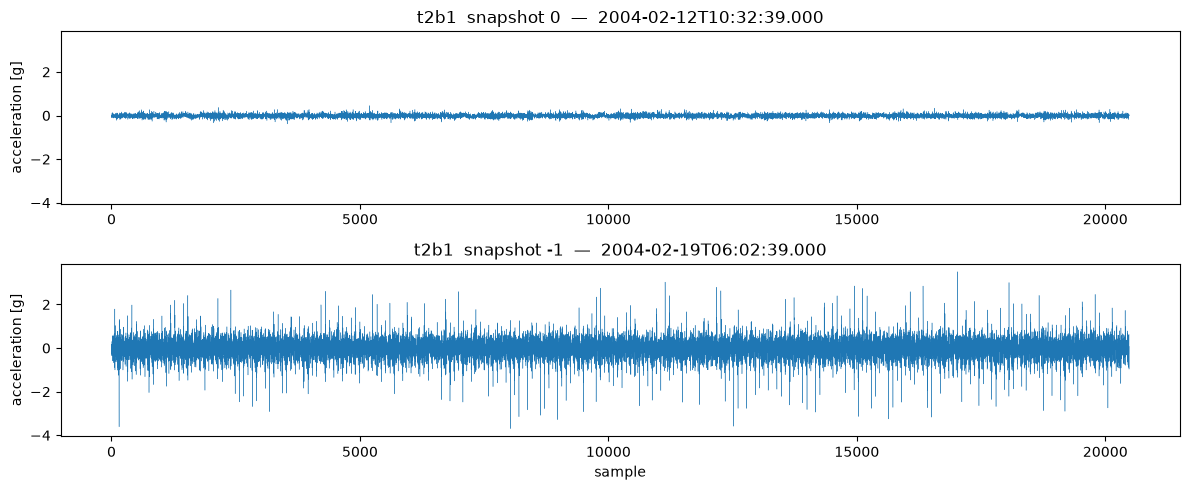

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)

for ax, i in zip(axes, [0, -1], strict=False):
    ax.plot(data.signals[i], lw=0.3)
    ax.set_title(f'{data.channel}  snapshot {i}  —  {data.timestamps[i]}')
    ax.set_ylabel('acceleration [g]')

axes[-1].set_xlabel('sample')
fig.tight_layout()

### compute time features

In [3]:
def time_features(signals: np.ndarray) -> pd.DataFrame:
    """(n_snapshots, 20480) -> DataFrame with 9 features per snapshot."""
    x = signals.astype(np.float64)
    mean = x.mean(axis=1)
    std = x.std(axis=1, ddof=1)
    rms = np.sqrt((x**2).mean(axis=1))
    centred = x - mean[:, None]
    return pd.DataFrame({
        'max': x.max(axis=1),
        'min': x.min(axis=1),
        'mean': mean,
        'std': std,
        'rms': rms,
        'skewness': (centred**3).mean(axis=1) / std**3,
        'kurtosis': (centred**4).mean(axis=1) / std**4 - 3,
        'crest_factor': x.max(axis=1) / rms,
        'form_factor': rms / mean,
    })


features = time_features(data.signals)
features.insert(0, 'timestamp', data.timestamps)
features.head()

,timestamp,max,min,mean,std,rms,skewness,kurtosis,crest_factor,form_factor
0,2004-02-12 10:32:39,0.454,-0.386,-0.010196,0.073477,0.074179,0.083987,0.628408,6.120331,-7.275307
1,2004-02-12 10:42:39,0.369,-0.388,-0.002585,0.075340,0.075382,0.052138,0.647935,4.895038,-29.161382
2,2004-02-12 10:52:39,0.503,-0.400,-0.002484,0.076191,0.076230,0.032806,0.513132,6.598472,-30.688508
3,2004-02-12 11:02:39,0.608,-0.576,-0.002277,0.078693,0.078724,0.041483,1.157547,7.723216,-34.579322
4,2004-02-12 11:12:39,0.391,-0.391,-0.002404,0.078439,0.078474,0.028222,0.602825,4.982524,-32.645152


In [4]:
all_channels = [c for channels in CHANNELS.values() for c in channels]

frames = []
for channel in all_channels:
    d = loader.load(channel)
    f = time_features(d.signals)
    f.insert(0, 'timestamp', d.timestamps)
    f.insert(0, 'channel', channel)
    frames.append(f)
    del d

features = pd.concat(frames, ignore_index=True)
features.shape

2026-08-25 16:20:22.082 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t1b1_x
2026-08-25 16:20:22.256 | INFO     | phm_101.data_loader:load:84 - Terminated loading IMS raw signals from parquet file for channel t1b1_x
2026-08-25 16:20:23.919 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t1b1_y
2026-08-25 16:20:24.095 | INFO     | phm_101.data_loader:load:84 - Terminated loading IMS raw signals from parquet file for channel t1b1_y
2026-08-25 16:20:25.761 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t1b2_x
2026-08-25 16:20:25.954 | INFO     | phm_101.data_loader:load:84 - Terminated loading IMS raw signals from parquet file for channel t1b2_x
2026-08-25 16:20:27.597 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t1b2_y
2026-08-25 16:20:27.798 | INFO     | phm_101.data_loader:load:84 - Term

(46468, 11)

### Valid end — when was the rig switched off?

During shutdown the accelerometers keep recording but there is no vibration, so those
snapshots have an RMS near zero and must be dropped.

In [6]:
shutdown = features[features['rms'] < 0.01]
print(f'{len(shutdown)} shutdown snapshots still present')
print(shutdown[['channel', 'timestamp', 'rms']].to_string(index=False))

print('\nlast valid timestamp per test:')
for test, channels in CHANNELS.items():
    good = features[features['channel'].isin(channels) & (features['rms'] >= 0.01)]
    print(f'  {test}: {good["timestamp"].max()}')

0 shutdown snapshots still present
Empty DataFrame
Columns: [channel, timestamp, rms]
Index: []

last valid timestamp per test:
  ImsTests.T1: 2003-11-25 23:39:56
  ImsTests.T2: 2004-02-19 06:02:39
  ImsTests.T3: 2004-04-18 02:32:55


The tail of each run, to see the cliff. The dashed line is the last snapshot with
real vibration; everything to the right of it is the rig winding down.

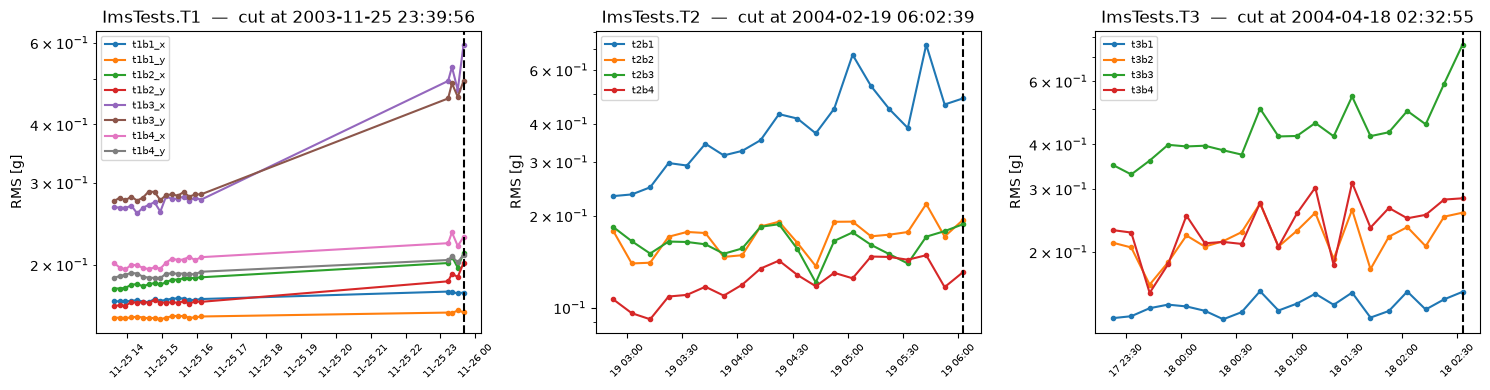

In [7]:
valid_end = {
    test: features[
        features['channel'].isin(channels) & (features['rms'] >= 0.01)
    ]['timestamp'].max()
    for test, channels in CHANNELS.items()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (test, channels) in zip(axes, CHANNELS.items(), strict=False):
    tail = features[features['channel'].isin(channels)]
    cutoff = tail['timestamp'].drop_duplicates().nlargest(20).min()
    tail = tail[tail['timestamp'] >= cutoff]

    for channel, group in tail.groupby('channel'):
        ax.plot(group['timestamp'], group['rms'], marker='o', ms=3, label=channel)

    ax.axvline(valid_end[test], ls='--', c='black')
    ax.set_yscale('log')
    ax.set_title(f'{test}  —  cut at {valid_end[test]}')
    ax.set_ylabel('RMS [g]')
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.legend(fontsize=7)

fig.tight_layout()

### Fault onset

Every bearing sits at a different baseline vibration level, so compare each channel to
**its own** healthy start: the median over its first 10% of life.

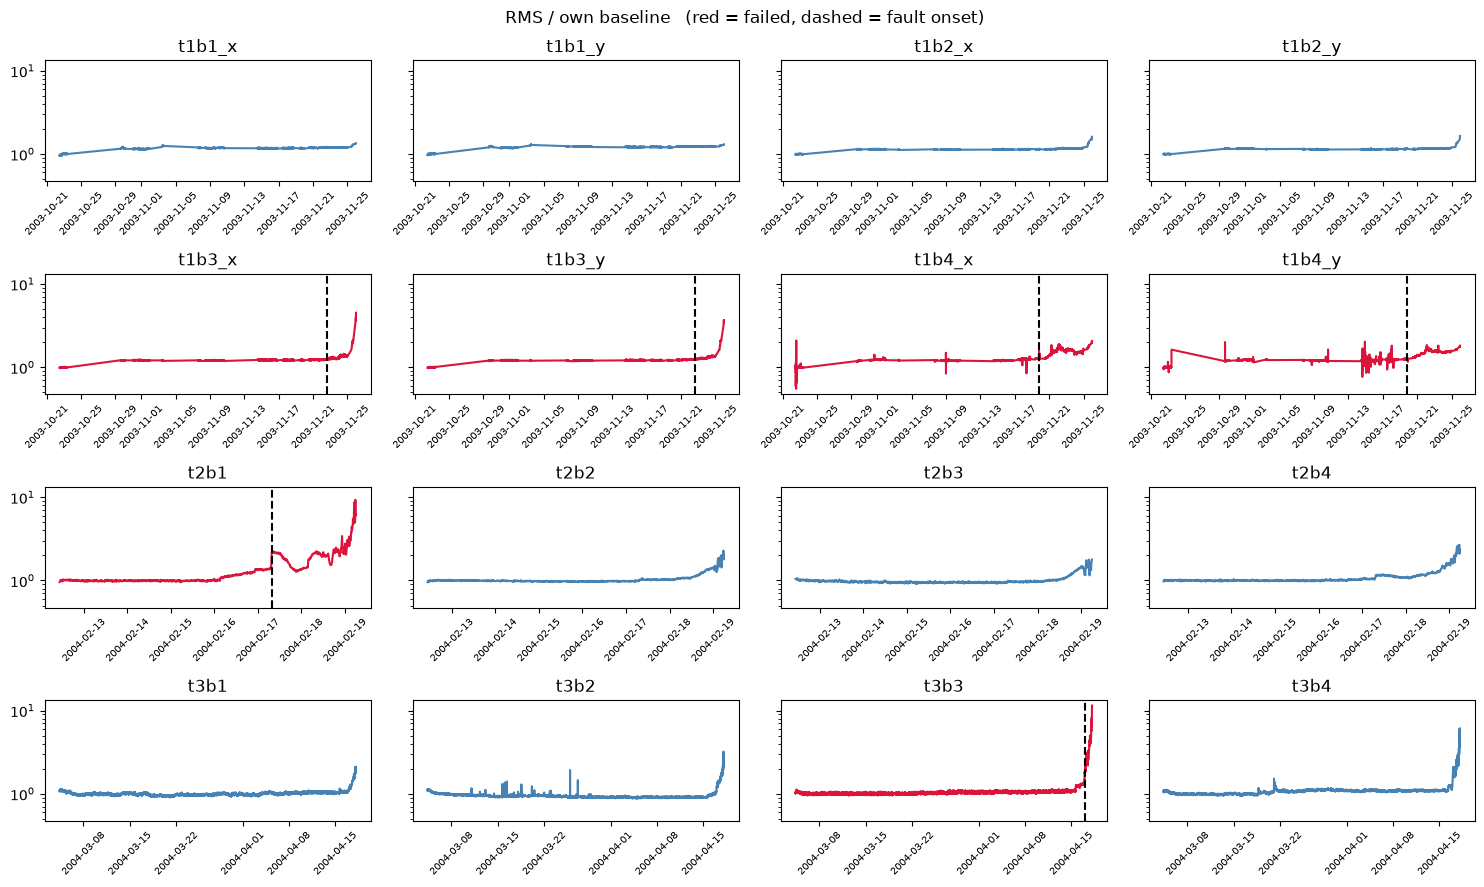

In [8]:
def baseline_ratio(group, column):
    values = group[column].to_numpy()
    return values / np.median(values[: len(values) // 10])


fig, axes = plt.subplots(4, 4, figsize=(15, 9), sharey=True)

for ax, (channel, group) in zip(axes.ravel(), features.groupby('channel')):
    onset = loader.fault_onset[channel]
    ax.plot(
        group['timestamp'],
        baseline_ratio(group, 'rms'),
        color='crimson' if onset else 'steelblue',
    )
    if onset:
        ax.axvline(np.datetime64(onset), ls='--', c='black')
    ax.set_title(channel)
    ax.set_yscale('log')
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)

fig.suptitle('RMS / own baseline   (red = failed, dashed = fault onset)')
fig.tight_layout()

The red channels climb far above their baseline and the blue ones stay near 1 — but
some healthy channels drift up too, because the whole rig shakes harder once one
bearing breaks up. So RMS alone is not enough to date the onset.

In [9]:
def first_sustained(group, column, factor, n=5):
    """First timestamp where a feature stays above factor x its baseline."""
    over = (baseline_ratio(group, column) > factor).astype(int)
    run = np.convolve(over, np.ones(n), 'valid') == n
    if not run.any():
        return pd.NaT
    return group['timestamp'].to_numpy()[int(np.argmax(run))]


summary = pd.DataFrame([
    {
        'channel': channel,
        'rms_peak': baseline_ratio(group, 'rms').max(),
        'kurtosis_max': group['kurtosis'].max(),
        'rms_onset': first_sustained(group, 'rms', 1.3),
        'kurtosis_onset': first_sustained(group, 'kurtosis', 4.0),
        'known_fault': loader.fault_onset[channel] is not None,
    }
    for channel, group in features.groupby('channel')
])
summary.round({'rms_peak': 2, 'kurtosis_max': 1})

,channel,rms_peak,kurtosis_max,rms_onset,kurtosis_onset,known_fault
0,t1b1_x,1.34,1.7,NaT,NaT,False
1,t1b1_y,1.31,3.1,NaT,NaT,False
2,t1b2_x,1.61,0.7,2003-11-25 12:27:32,NaT,False
3,t1b2_y,1.65,0.9,2003-11-25 12:57:32,NaT,False
4,t1b3_x,4.51,71.6,2003-11-24 02:11:24,2003-11-22 14:16:56,True
5,t1b3_y,3.69,15.9,2003-11-24 02:11:24,2003-11-24 02:51:24,True
6,t1b4_x,2.10,71.5,2003-11-20 17:39:03,2003-11-19 19:46:07,True
7,t1b4_y,2.03,56.4,2003-11-20 14:04:03,2003-11-21 03:54:03,True
8,t2b1,9.33,14.1,2004-02-16 22:22:39,2004-02-17 07:32:39,True
9,t2b2,2.29,2.5,2004-02-18 19:52:39,NaT,False


Kurtosis is the better discriminator. Impacts from a spalled surface make the signal
spiky well before its overall energy rises, so kurtosis fires on the damaged channels
and stays quiet on the healthy ones — where RMS alone gives false positives.

Taking the earlier of the two as the onset:

In [11]:
onsets = summary.copy()
onsets['onset'] = onsets[['rms_onset', 'kurtosis_onset']].min(axis=1)

for row in onsets.itertuples():
    value = f"'{row.onset}'" if row.known_fault else 'None'
    print(f"    '{row.channel}': {value},")

    't1b1_x': None,
    't1b1_y': None,
    't1b2_x': None,
    't1b2_y': None,
    't1b3_x': '2003-11-22 14:16:56',
    't1b3_y': '2003-11-24 02:11:24',
    't1b4_x': '2003-11-19 19:46:07',
    't1b4_y': '2003-11-20 14:04:03',
    't2b1': '2004-02-16 22:22:39',
    't2b2': None,
    't2b3': None,
    't2b4': None,
    't3b1': None,
    't3b2': None,
    't3b3': '2004-04-16 15:42:55',
    't3b4': None,


### Check the labels

2026-08-25 16:22:40.280 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t2b1
2026-08-25 16:22:40.366 | INFO     | phm_101.data_loader:load:84 - Terminated loading IMS raw signals from parquet file for channel t2b1
2026-08-25 16:22:41.106 | INFO     | phm_101.data_loader:load:51 - Loading IMS raw signals from parquet file for channel t3b3
2026-08-25 16:22:41.575 | INFO     | phm_101.data_loader:load:84 - Terminated loading IMS raw signals from parquet file for channel t3b3


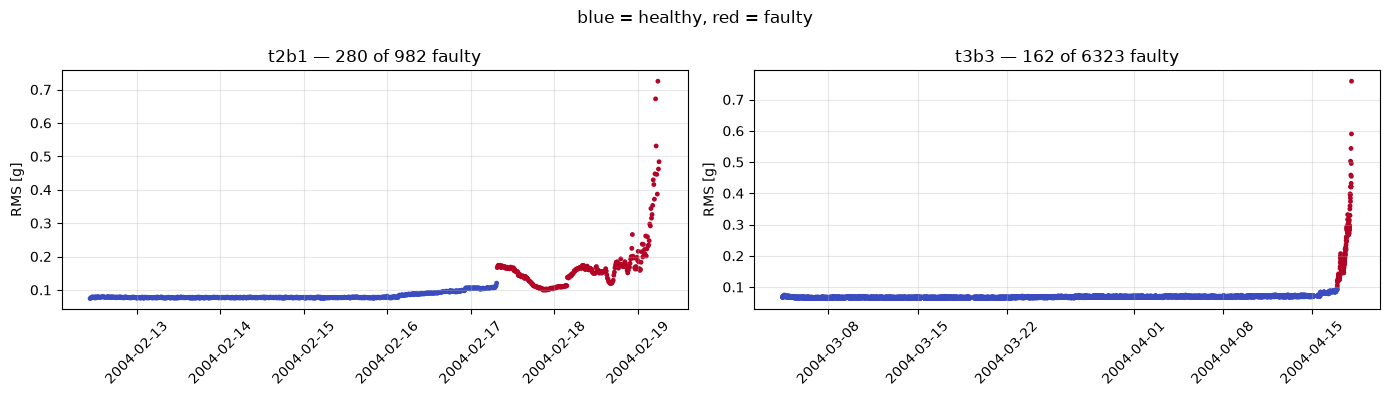

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, channel in zip(axes, ['t2b1', 't3b3']):
    d = loader.load(channel)
    f = time_features(d.signals)
    ax.scatter(d.timestamps, f['rms'], c=d.labels, cmap='coolwarm', s=6)
    ax.set_title(f'{channel} — {int(d.labels.sum())} of {len(d)} faulty')
    ax.set_ylabel('RMS [g]')
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(alpha=0.3)

fig.suptitle('blue = healthy, red = faulty')
fig.tight_layout()